In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
df = pd.read_csv("carbon_dataset.csv")
print(df.head())

  Language  Complexity_Score  Nesting_Depth   Memory_MB      Joules
0        C                52              5   99.883047   86.867869
1        C                83              3  235.031957  121.036475
2        C               100              3   20.086402   77.817275
3        C                21              1  159.078699   45.931206
4        C                22              5  221.653059   94.612439


In [4]:
le = LabelEncoder()
df["Language_Encoded"] = le.fit_transform(df["Language"])

In [5]:
X = df[
    [
        "Language_Encoded",
        "Complexity_Score",
        "Nesting_Depth",
        "Memory_MB"
    ]
]

y = df["Joules"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
rf_model = RandomForestRegressor(
    n_estimators=250,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)



lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

In [8]:
print("===== RANDOM FOREST =====")
print("R² :", r2_score(y_test, y_pred_rf))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

print("\n===== LINEAR REGRESSION =====")
print("R² :", r2_score(y_test, y_pred_lr))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

===== RANDOM FOREST =====
R² : 0.9905165634694826
RMSE : 299.7703224564554

===== LINEAR REGRESSION =====
R² : 0.61892666656023
RMSE : 1900.2469476252404


In [18]:
with open("energy_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

print("Model Saved")

Model Saved


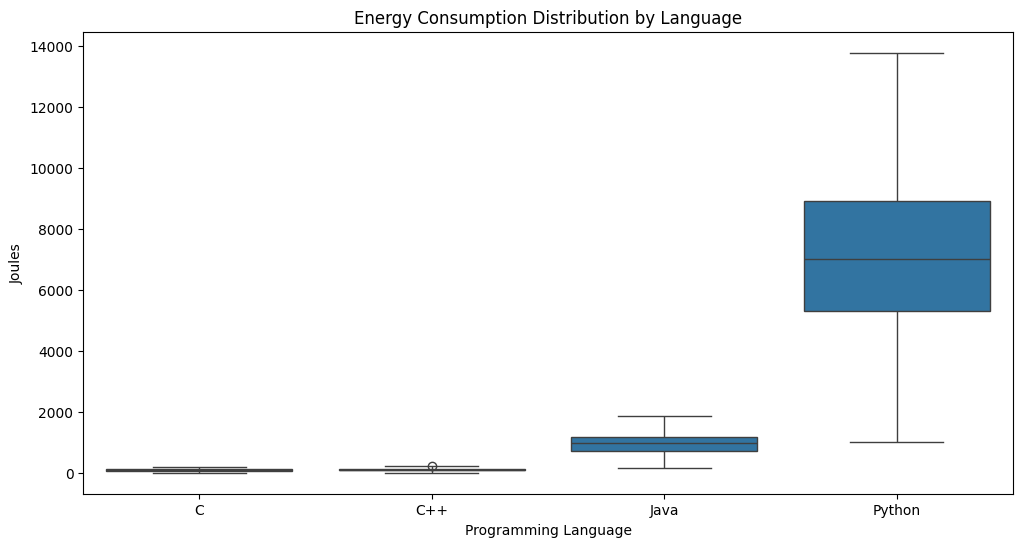

In [10]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x="Language",
    y="Joules",
    data=df
)

plt.title("Energy Consumption Distribution by Language")
plt.xlabel("Programming Language")
plt.ylabel("Joules")
plt.show()

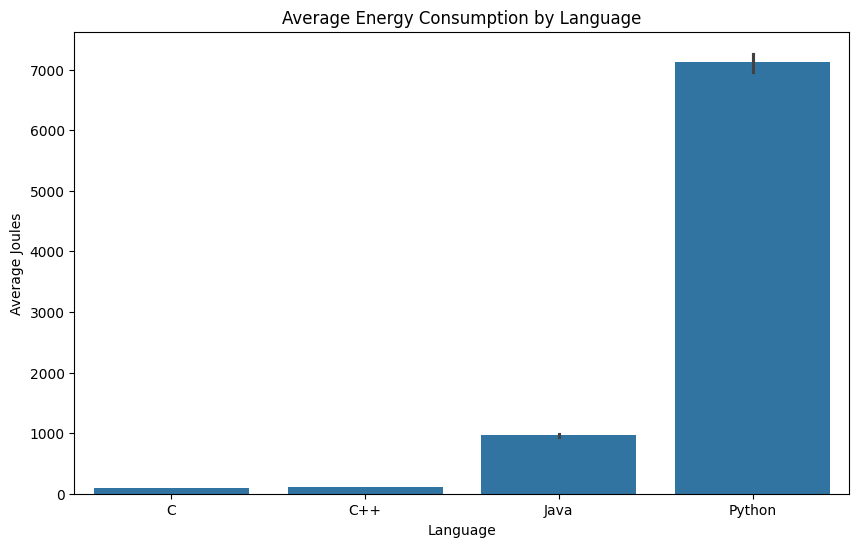

In [11]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Language",
    y="Joules",
    data=df
)

plt.title("Average Energy Consumption by Language")
plt.ylabel("Average Joules")
plt.show()

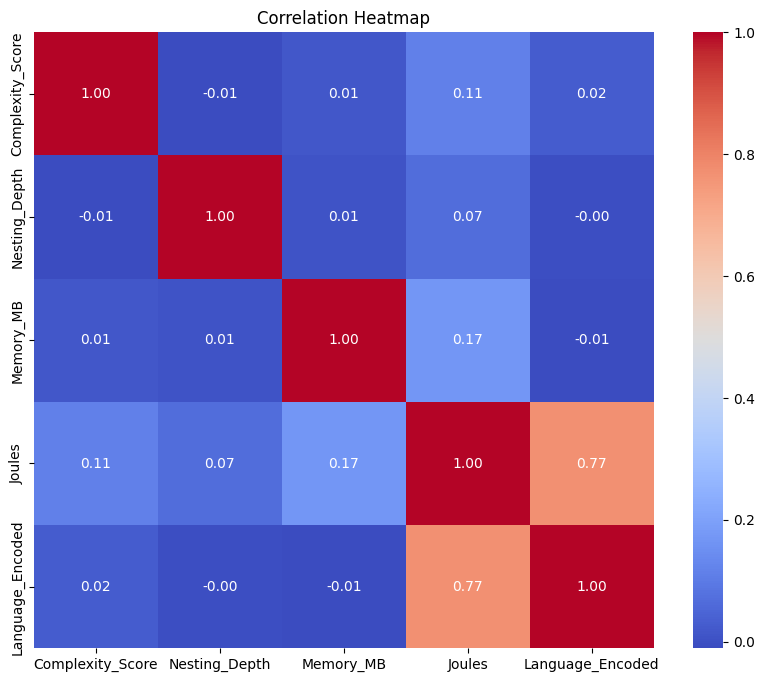

In [12]:
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()


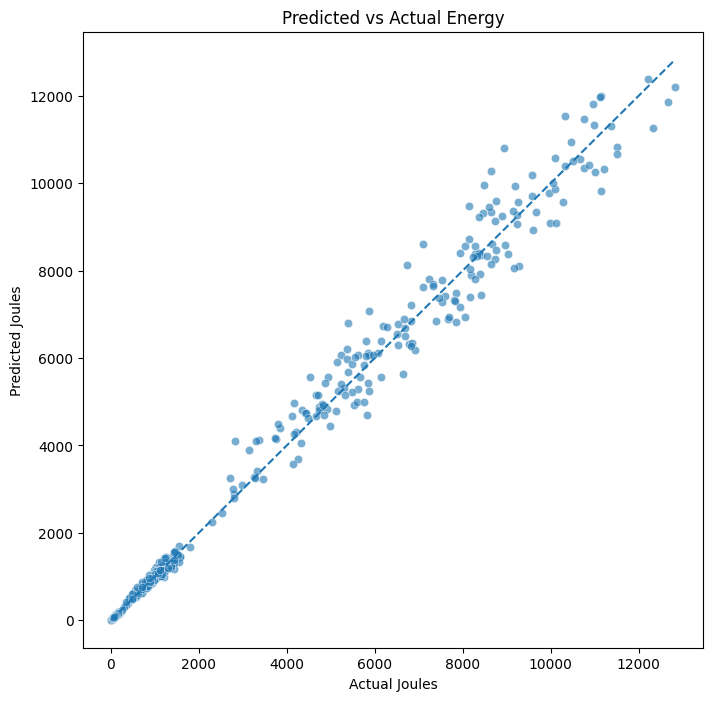

In [13]:
plt.figure(figsize=(8,8))

sns.scatterplot(
    x=y_test,
    y=y_pred_rf,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Joules")
plt.ylabel("Predicted Joules")
plt.title("Predicted vs Actual Energy")
plt.show()

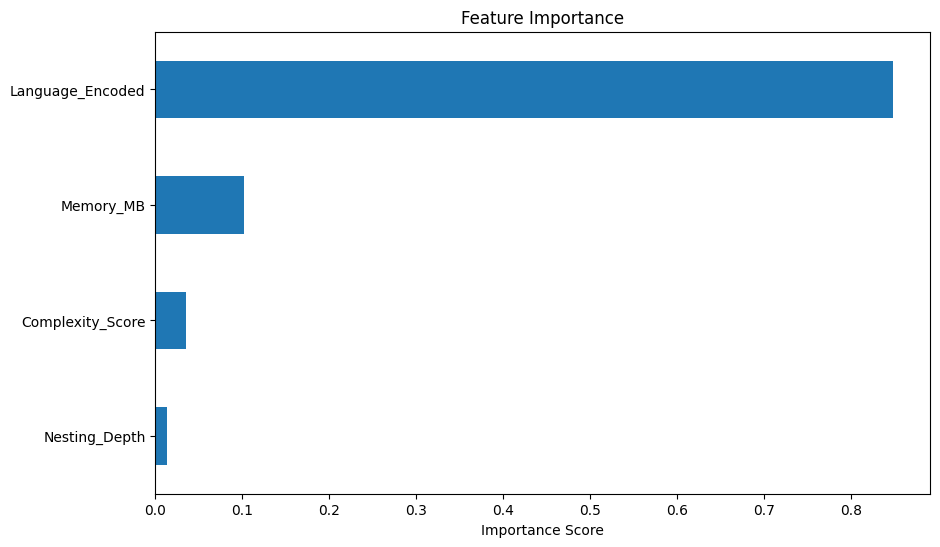

In [14]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot.barh(
    figsize=(10,6)
)

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()


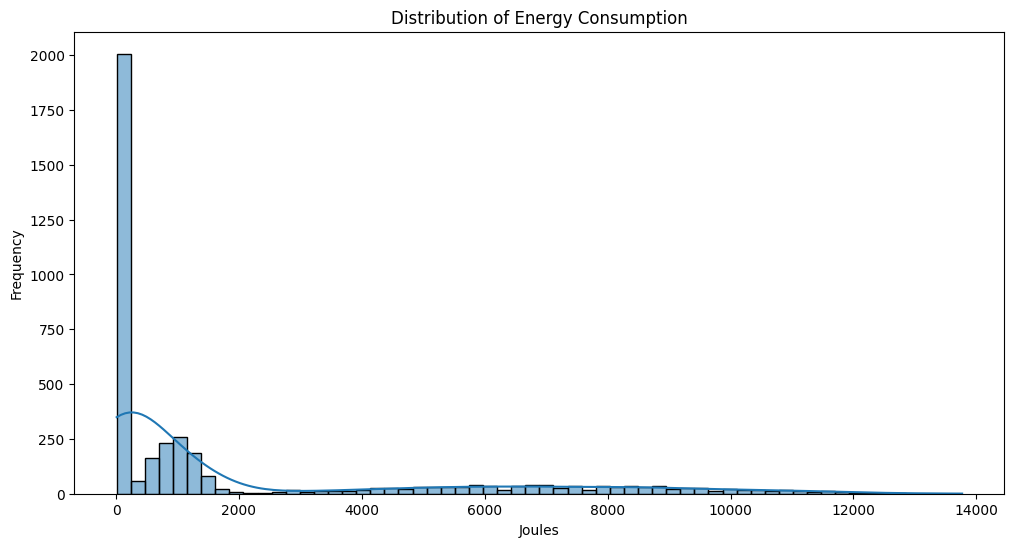

In [15]:
plt.figure(figsize=(12,6))

sns.histplot(
    df["Joules"],
    bins=60,
    kde=True
)

plt.title("Distribution of Energy Consumption")
plt.xlabel("Joules")
plt.ylabel("Frequency")
plt.show()


In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("=== Random Forest ===")
print("R²  :", r2_score(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

print("\n=== Linear Regression ===")
print("R²  :", r2_score(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

=== Random Forest ===
R²  : 0.9905165634694826
RMSE: 299.7703224564554

=== Linear Regression ===
R²  : 0.61892666656023
RMSE: 1900.2469476252404


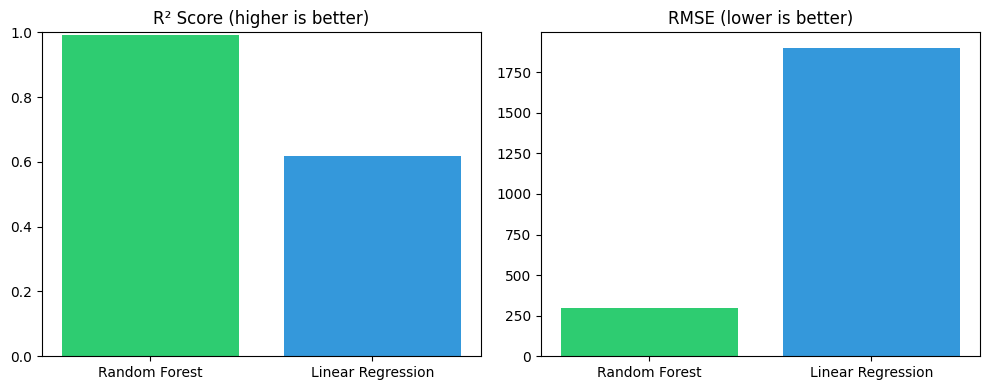

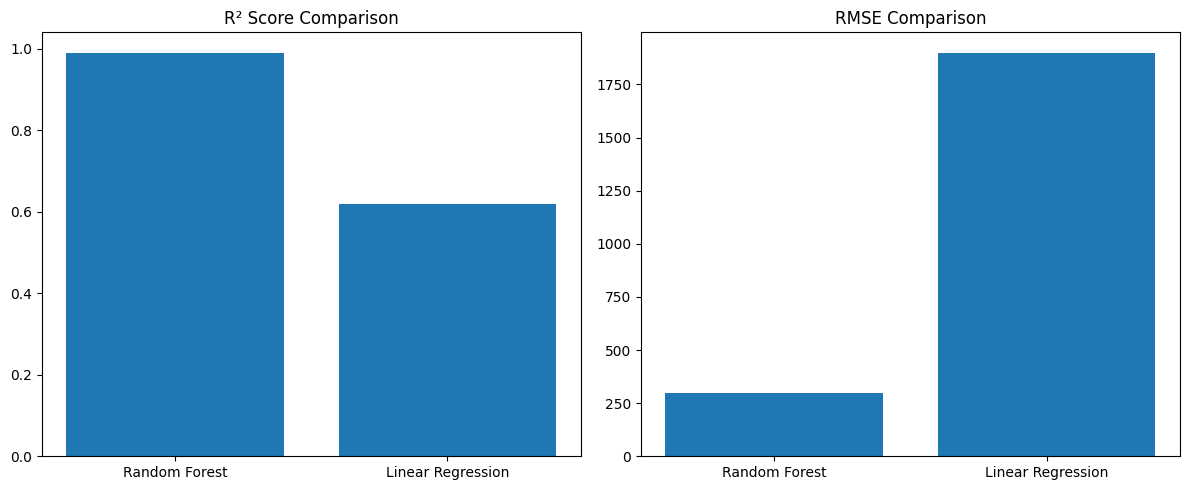

In [16]:
models = [
    "Random Forest",
    "Linear Regression"
]

r2_scores = [
    r2_score(y_test, y_pred_rf),
    r2_score(y_test, y_pred_lr)
]

rmse_scores = [
    np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    np.sqrt(mean_squared_error(y_test, y_pred_lr))
]


fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

ax1.bar(models, r2_scores)
ax1.set_title("R² Score Comparison")

ax2.bar(models, rmse_scores)
ax2.set_title("RMSE Comparison")

plt.tight_layout()
plt.show()

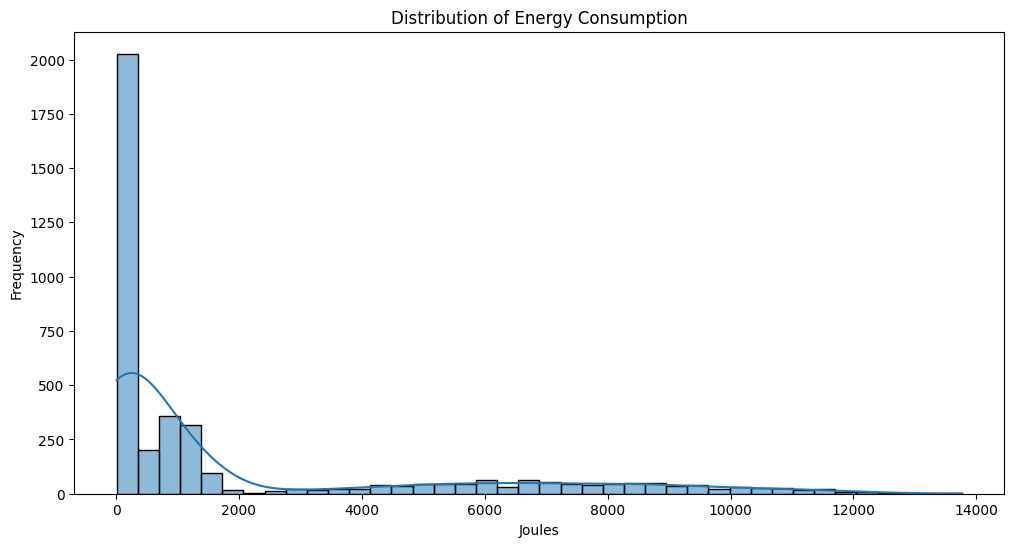

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("carbon_dataset.csv")

# Create histogram
plt.figure(figsize=(12,6))

sns.histplot(
    df["Joules"],
    bins=40,
    kde=True
)

plt.title("Distribution of Energy Consumption")
plt.xlabel("Joules")
plt.ylabel("Frequency")

# Save high-quality image for thesis
plt.savefig(
    "energy_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
import os
import time

print(time.ctime(os.path.getmtime("energy_model.pkl")))

Thu May 21 16:03:49 2026


In [20]:
import os
import time

print(time.ctime(os.path.getmtime("energy_model.pkl")))

Thu May 21 16:03:49 2026


In [21]:
print(rf_model.feature_names_in_)

['Language_Encoded' 'Complexity_Score' 'Nesting_Depth' 'Memory_MB']
